# This contains code for the BST side of the analysis (Johnathan E. 4/24/2026/)

**Questions:** What price for each Model of iPhone is fair?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

RAW_PATH = 'ecommerce_iphone_resale_cleaned.csv'

rawData = pd.read_csv(RAW_PATH)
rawData.head()

,title,model_family,generation_number,is_pro,storage_gb_numeric,condition,price,wasPrice,price_discount_pct,available,sold,was_lot
0,Apple iPhone 14 Pro MAX 1 TB Deep purple (Factory Unlocked),iPhone 14 Pro Max,14.0,True,1024.0,Used,628.99,NaN,NaN,0.0,1.0,False
1,Apple iPhone 14 Pro Max - 128 GB - ALL COLORS (Unlocked)- Very Good Refurb,iPhone 14 Pro Max,14.0,True,128.0,Very Good - Refurbished,469.99,NaN,NaN,5.0,2.0,False
2,open box Apple iPhone 14 Pro MAX 256GB FULLY Unlocked,iPhone 14 Pro Max,14.0,True,256.0,Open Box,729.99,NaN,NaN,0.0,2.0,False
3,Apple iPhone 14 -5G - 512GB Factory Unlocked GSM + CDMA - EXCELLENT,iPhone 14,14.0,False,512.0,Excellent - Refurbished,397.48,NaN,NaN,9.0,30.0,False
4,OPEN BOX Apple iPhone 17 A3258 256GB 512GB BLACK SAGE LAVENDER BLUE (Unlocked),iPhone 17,17.0,False,256.0,Open Box,779.00,NaN,NaN,0.0,48.0,False


## 1. Classes

In [2]:
class Node:
    def __init__(self, key, record):
        self.key = key
        self.records = [record]
        self.left = None
        self.right = None
        self.size = 1

In [3]:
class BST:
    def __init__(self, key_col, name=""):
        self.root = None
        self.key_col = key_col
        self.name = name

    # ------------------------------------------------------------------ #
    #  Core BST methods                                                    #
    # ------------------------------------------------------------------ #
    def _insert(self, node, key, record):
        if node is None:
            return Node(key, record)
        if key < node.key:
            node.left = self._insert(node.left, key, record)
        elif key > node.key:
            node.right = self._insert(node.right, key, record)
        else:
            node.records.append(record)
        node.size = len(node.records) + self._size(node.left) + self._size(node.right)
        return node

    def insert(self, key, record):
        self.root = self._insert(self.root, key, record)

    def _size(self, node):
        return node.size if node else 0

    def from_dataframe(self, df):
        for _, row in df.iterrows():
            self.insert(row[self.key_col], row.to_dict())

    def search(self, key):
        return self._search(self.root, key)

    def _search(self, node, key):
        if node is None:
            return None
        if key == node.key:
            return node.records
        elif key < node.key:
            return self._search(node.left, key)
        else:
            return self._search(node.right, key)

    # ------------------------------------------------------------------ #
    #  Validation helper                                                   #
    # ------------------------------------------------------------------ #
    def _get_col_values(self, col_name):
        """
        In-order generator of (value, count) for a given column.
        Returns False if:
          - tree is empty
          - col_name is missing from any record
          - any value for that column is non-numeric
        """
        if self.root is None:
            return False

        pairs = []
        for key, count in self._inorder(self.root):
            # use the first record at this node to read the column value
            sample = self._get_node(self.root, key).records[0]
            if col_name not in sample:
                return False
            val = sample[col_name]
            try:
                val = float(val)
                if val != val:   # NaN check
                    return False
            except (TypeError, ValueError):
                return False
            pairs.append((val, count))
        return pairs

    def _get_node(self, node, key):
        """Return the node matching key."""
        if node is None:
            return None
        if key == node.key:
            return node
        elif key < node.key:
            return self._get_node(node.left, key)
        else:
            return self._get_node(node.right, key)

    # ------------------------------------------------------------------ #
    #  In-order helper                                                     #
    # ------------------------------------------------------------------ #
    def _inorder(self, node):
        if node is None:
            return
        yield from self._inorder(node.left)
        yield (node.key, len(node.records))
        yield from self._inorder(node.right)

    # ------------------------------------------------------------------ #
    #  Summation                                                           #
    # ------------------------------------------------------------------ #
    def summation(self, col_name):
        pairs = self._get_col_values(col_name)
        if pairs is False:
            return False
        return sum(val * count for val, count in pairs)

    # ------------------------------------------------------------------ #
    #  Count                                                               #
    # ------------------------------------------------------------------ #
    def count(self, col_name=None):
        """
        If col_name is given, counts only records where that column
        is a valid numeric value. Otherwise returns total record count.
        """
        if col_name is None:
            return self._size(self.root)
        pairs = self._get_col_values(col_name)
        if pairs is False:
            return False
        return sum(count for _, count in pairs)

    # ------------------------------------------------------------------ #
    #  Average                                                             #
    # ------------------------------------------------------------------ #
    def average(self, col_name):
        n = self.count(col_name)
        if n is False or n == 0:
            return False
        total = self.summation(col_name)
        if total is False:
            return False
        return total / n

    # ------------------------------------------------------------------ #
    #  Standard Deviation                                                  #
    # ------------------------------------------------------------------ #
    def std_dev(self, col_name):
        n = self.count(col_name)
        if n is False or n == 0:
            return False
        mu = self.average(col_name)
        if mu is False:
            return False
        pairs = self._get_col_values(col_name)
        if pairs is False:
            return False
        variance = sum(((val - mu) ** 2) * count for val, count in pairs) / n
        return variance ** 0.5

    # ------------------------------------------------------------------ #
    #  Percentile                                                          #
    # ------------------------------------------------------------------ #
    def percentile(self, col_name, pct):
        if not 0 <= pct <= 100:
            return False
        pairs = self._get_col_values(col_name)
        if pairs is False:
            return False

        pairs_sorted = sorted(pairs, key=lambda x: x[0])
        n = sum(count for _, count in pairs_sorted)
        if n == 0:
            return False

        target = (pct / 100) * n
        cumulative = 0
        prev_val = None

        for val, count in pairs_sorted:
            prev_cumulative = cumulative
            cumulative += count

            if prev_cumulative < target <= cumulative:
                return val

            if prev_val is not None and prev_cumulative >= target:
                return (prev_val + val) / 2

            prev_val = val

        return prev_val

In [4]:
class ModelFamilyVector:
    def __init__(self, key_col="price"):
        self.key_col = key_col
        self.vector = []          # list of BSTs, one per model_family

    def from_dataframe(self, df):
        for family, group in df.groupby("model_family"):
            bst = BST(key_col=self.key_col, name=family)
            bst.from_dataframe(group)
            self.vector.append(bst)

    def search(self, model_family):
        """Return the BST for a given model_family, or None if not found."""
        for bst in self.vector:
            if bst.name == model_family:
                return bst
        return None

    def families(self):
        """List all model families in the vector."""
        return [bst.name for bst in self.vector]

    def __len__(self):
        return len(self.vector)

    def __getitem__(self, index):
        return self.vector[index]

## 2. Dataframe -> BST

In [5]:
fullBST = BST(key_col="price")
fullBST.from_dataframe(rawData)

print(fullBST.root.size)           #Unique data points

# search returns all listings at that price
results = fullBST.search(329.99)
print(len(results))            # how many phones listed at $329.99 #12
print(results[0])              # first match record

912
5
{'title': 'open box Apple iPhone 13 128GB Blue Unlocked 1 year ex warranty', 'model_family': 'iPhone 13', 'generation_number': 13.0, 'is_pro': False, 'storage_gb_numeric': 128.0, 'condition': 'Open Box', 'price': 329.99, 'wasPrice': nan, 'price_discount_pct': nan, 'available': 0.0, 'sold': 1.0, 'was_lot': False}


## 3. Individual BST's for each "model_family"
This is so we can get a fair price for each of the models

In [6]:
mv = ModelFamilyVector(key_col="price")
mv.from_dataframe(rawData)

print(mv.families()) #see all families loaded

print(sum(bst.root.size for bst in mv))   #Sanity Check = 2371

['iPhone 12', 'iPhone 12 Mini', 'iPhone 12 Pro', 'iPhone 12 Pro Max', 'iPhone 12Pro Max', 'iPhone 13', 'iPhone 13 Mini', 'iPhone 13 Pro Max', 'iPhone 14', 'iPhone 14 Plus', 'iPhone 14 Pro Max', 'iPhone 15', 'iPhone 15 Plus', 'iPhone 15 Pro', 'iPhone 15 Pro Max', 'iPhone 16', 'iPhone 17', 'iPhone 17 Pro Max']
912


In [7]:
# grab the BST for a specific family
iphone14_bst = mv.search("iPhone 14")
print(iphone14_bst.name)
print(iphone14_bst.root.size)

# search that family's BST by price
listings = iphone14_bst.search(329.99)
print(listings)

iPhone 14
131
[{'title': 'Apple iPhone 14 128gb white color Factory Unlocked', 'model_family': 'iPhone 14', 'generation_number': 14.0, 'is_pro': False, 'storage_gb_numeric': 128.0, 'condition': 'Used', 'price': 329.99, 'wasPrice': nan, 'price_discount_pct': nan, 'available': 2.0, 'sold': 1.0, 'was_lot': False}]


## 4. Get statistical data for a single Model

In [8]:
iphone14_bst = mv.search("iPhone 14")

#Collumns given must be Numeric
print("price sum: " + str(iphone14_bst.summation("price")))

print("price count: " + str(iphone14_bst.count("price")))
print("count: " + str(iphone14_bst.count()))

print("avg price: " + str(iphone14_bst.average("price")))

print("sd price: " + str(iphone14_bst.std_dev("price")))
print("sd storage_gb: " + str(iphone14_bst.std_dev("storage_gb_numeric")))

print("price 25th: " + str(iphone14_bst.percentile("price", 25)))
print("price median: " + str(iphone14_bst.percentile("price", 50)))
print("price 75th: " + str(iphone14_bst.percentile("price", 75)))

price sum: 39341.79
price count: 131
count: 131
avg price: 300.3190076335878
sd price: 84.427794208383
sd storage_gb: 99.51073363228542
price 25th: 232.0
price median: 280.2
price 75th: 379.0


## 5. Do it for all

In [9]:
summary_rows = []

for bst in mv:
    summary_rows.append({
        "Model Family": bst.name,
        "Sum":          round(bst.summation("price"), 2),
        "Count":        bst.count(),
        "Avg":          round(bst.average("price"), 2),
        "StdDev":       round(bst.std_dev("price"), 2),
        "25th":         round(bst.percentile("price", 25), 2),
        "Median":       round(bst.percentile("price", 50), 2),
        "75th":         round(bst.percentile("price", 75), 2),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Model Family")
summary_df.style.format({
        "Sum":    "${:,.2f}",
        "Avg":    "${:,.2f}",
        "StdDev": "${:,.2f}",
        "25th":   "${:,.2f}",
        "Median": "${:,.2f}",
        "75th":   "${:,.2f}",
        "Count":  "{:,}",})
summary_df

,Sum,Count,Avg,StdDev,25th,Median,75th
Model Family,,,,,,,
iPhone 12,21932.16,125,175.46,59.40,149.00,156.00,165.00
iPhone 12 Mini,1938.50,6,323.08,8.97,314.11,314.11,332.08
iPhone 12 Pro,1292.31,4,323.08,8.97,314.11,314.11,332.01
iPhone 12 Pro Max,11417.95,32,356.81,93.74,309.99,330.75,349.99
iPhone 12Pro Max,328.07,1,328.07,0.00,328.07,328.07,328.07
iPhone 13,34867.68,127,274.55,87.05,214.00,227.00,315.97
iPhone 13 Mini,47734.16,150,318.23,45.78,321.01,321.88,323.99
iPhone 13 Pro Max,1030.73,3,343.58,48.05,297.79,322.99,409.95
iPhone 14,39341.79,131,300.32,84.43,232.00,280.20,379.00


## 6. Drop count < 30 (Central Limit Theorem) and construct 95% Confidence Interval

In [10]:
# Drop models with count < 30
mv.vector = [bst for bst in mv if bst.count() >= 30]
ci_rows = []

for bst in mv:
    n      = bst.count()
    avg    = bst.average("price")
    sd     = bst.std_dev("price")
    moe     = sd / (n ** 0.5)
    z_crit = 1.96 #zTable (Normality is passed by CLT)
    margin = z_crit * moe

    ci_rows.append({
        "Model Family": bst.name,
        "Count":        n,
        "Avg Price":    round(avg, 2),
        "StdDev":       round(sd, 2),
        "MOE":           round(moe, 4),
        "Lower 95% CI": round(avg - margin, 2),
        "Upper 95% CI": round(avg + margin, 2),
    })

ci_df = pd.DataFrame(ci_rows).set_index("Model Family")

(ci_df.style
    .set_caption("95% Confidence Interval for Price by Model Family (n ≥ 30)")
    .format({
        "Avg Price":    "${:,.2f}",
        "StdDev":       "${:,.2f}",
        "MOE":           "${:,.4f}",
        "Lower 95% CI": "${:,.2f}",
        "Upper 95% CI": "${:,.2f}",
        "Count":        "{:,}",
    })
)

,Count,Avg Price,StdDev,MOE,Lower 95% CI,Upper 95% CI
Model Family,,,,,,
iPhone 12,125,$175.46,$59.40,$5.3127,$165.04,$185.87
iPhone 12 Pro Max,32,$356.81,$93.74,$16.5706,$324.33,$389.29
iPhone 13,127,$274.55,$87.05,$7.7248,$259.41,$289.69
iPhone 13 Mini,150,$318.23,$45.78,$3.7381,$310.90,$325.55
iPhone 14,131,$300.32,$84.43,$7.3765,$285.86,$314.78
iPhone 14 Plus,42,$334.43,$76.11,$11.7447,$311.41,$357.45
iPhone 14 Pro Max,79,$624.45,$192.34,$21.6404,$582.03,$666.86
iPhone 15,37,$408.56,$38.43,$6.3173,$396.18,$420.94
iPhone 16,45,$589.72,$68.74,$10.2470,$569.63,$609.80


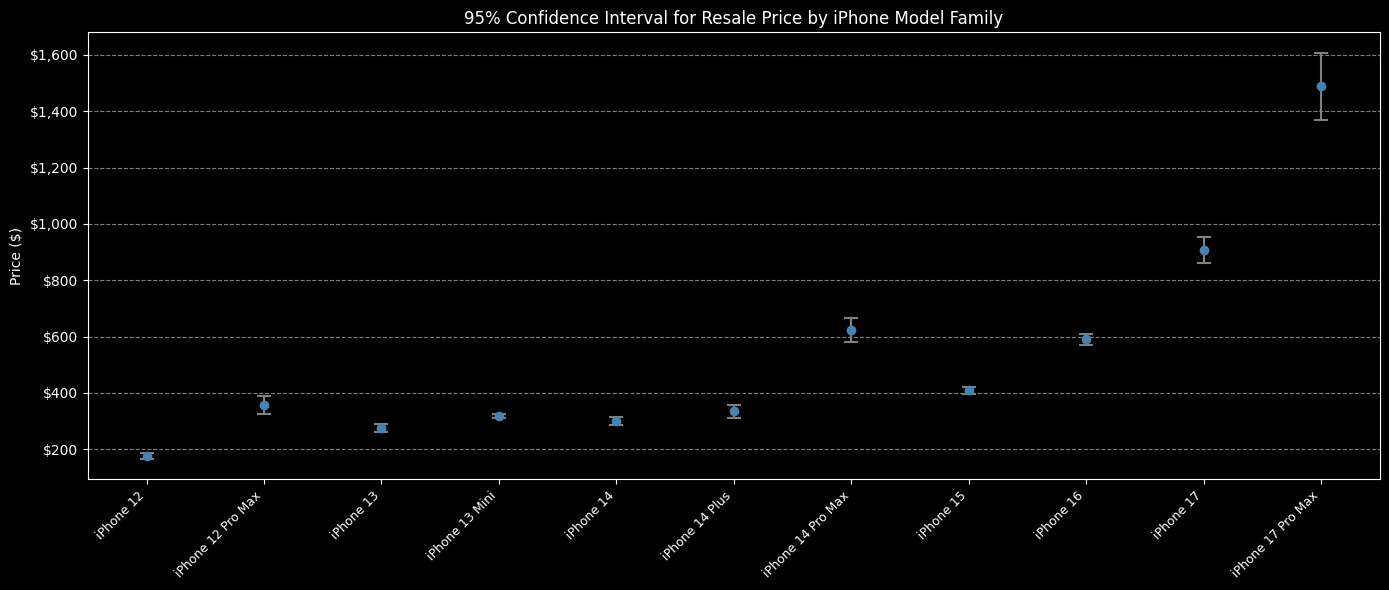

In [11]:
models = ci_df.index.tolist()
avgs   = ci_df["Avg Price"].tolist()
lowers = ci_df["Lower 95% CI"].tolist()
uppers = ci_df["Upper 95% CI"].tolist()

yerr_lower = [avg - lo for avg, lo in zip(avgs, lowers)] #annoying
yerr_upper = [up - avg for avg, up in zip(avgs, uppers)]

fig, ax = plt.subplots(figsize=(14, 6))

ax.errorbar(
    x=range(len(models)),
    y=avgs,
    yerr=[yerr_lower, yerr_upper],
    fmt="o",
    capsize=5,
    capthick=1.5,
    elinewidth=1.5,
    markersize=6,
    color="steelblue",
    ecolor="gray",
)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Price ($)")
ax.set_title("95% Confidence Interval for Resale Price by iPhone Model Family")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
awt = mv.search("iPhone 14")
for i in range(1_000):
    awt.summation("price")